In [148]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [149]:
df=pd.read_excel("../data/co2 solubility dataset.xlsx",sheet_name=4)

In [150]:
df.head()

,IL NAME,CATION NAME,ANION NAME,Cation_SMILES,Anion_SMILES,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
0,[Bmim][PF6],1-butyl-3-methyl-imidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,25.0,83.0,0.75
1,[Emim][Tf2N],1-ethyl-3-methylimidazolium,bis(trifluoromethylsulfonyl)imide,CC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,100.0,13.0,0.17
2,[Bmim][Tf2N],1-butyl-3-methyl-imidazolium,bis(trifluoromethylsulfonyl)imide,CCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,100.0,13.0,0.18
3,[Omim][Tf2N],1-octyl-3-methyl-imidazolium,bis(trifluoromethylsulfonyl)imide,CCCCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,100.0,13.0,0.19
4,[C12mim][Tf2N],1-dodecyl-3-methyl-imidazolium,bis(trifluoromethylsulfonyl)imide,CCCCCCCCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,100.0,13.0,0.21


In [151]:
df.sample(5)

,IL NAME,CATION NAME,ANION NAME,Cation_SMILES,Anion_SMILES,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
1651,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,60.15,62.770,0.615509
997,[EMIM][TCM],1-ethyl-3-methyl-1H-imidazolium,tricyanomethanide,CC[n+]1ccn(C)c1,C([C-](C#N)C#N)#N,50.00,12.940,0.160497
2716,[BMIM][L-Val],1-butyl-3-methylimidazolium,L-valinate,CCCC[n+]1ccn(C)c1,CC(C)[C@@H](C(=O)[O-])N,25.00,1.038,0.282173
5295,[N112(MEE)][NTf₂],"N-ethyl-2-(2-methoxyethoxy)-N,N-dimethylethana...",bis(trifluoromethylsulfonyl)imide,COCCOCC[N+](C)(C)CC,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,60.00,15.443,0.308901
4789,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,60.00,75.020,1.499375


In [152]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5462 entries, 0 to 5461
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   IL NAME                        5462 non-null   str    
 1   CATION NAME                    5462 non-null   str    
 2   ANION NAME                     5462 non-null   str    
 3   Cation_SMILES                  5462 non-null   str    
 4   Anion_SMILES                   5462 non-null   str    
 5   Temperature (0 C)              5462 non-null   float64
 6   Pressure (bar)                 5462 non-null   float64
 7   CO2 capacity (mol CO2/mol IL)  5462 non-null   float64
dtypes: float64(3), str(5)
memory usage: 341.5 KB


In [ ]:
df.describe()
#to see statistical description of the raw data

,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
count,5462.000000,5462.000000,5462.000000
mean,43.052819,16.705380,2.181734
std,21.032388,28.280796,135.291052
min,4.970000,0.000013,0.000000
25%,25.000000,2.000000,0.072612
50%,40.000000,8.500000,0.188106
75%,59.980000,16.999000,0.414427
max,139.950000,345.500000,9999.000000


In [ ]:
df.isnull().sum()
#to see if any column has any null or missing value==> which comes out to be zero

IL NAME                          0
CATION NAME                      0
ANION NAME                       0
Cation_SMILES                    0
Anion_SMILES                     0
Temperature (0 C)                0
Pressure (bar)                   0
CO2 capacity (mol CO2/mol IL)    0
dtype: int64

In [ ]:
print(df.duplicated(subset=df.columns,keep=False).sum())
#checking if rows are exactly duplicate having all values same==> which came out to be around 222

222


In [156]:
df[df.duplicated(subset=df.columns,keep=False)]

,IL NAME,CATION NAME,ANION NAME,Cation_SMILES,Anion_SMILES,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
79,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,6.0,0.161440
80,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,6.0,0.161440
85,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,7.5,0.201923
86,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,7.5,0.201923
91,[BMIM][PF6],1-butyl-3-methylimidazolium,hexafluorophosphate,CCCC[n+]1ccn(C)c1,F[P-](F)(F)(F)(F)F,9.95,9.0,0.243781
...,...,...,...,...,...,...,...,...
4768,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,24.25,1.0,0.030928
4777,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,24.25,14.8,0.540832
4778,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,24.25,14.8,0.540832
5184,[P1444i][OTs],triisobutylmethylphosphonium,p-toluenesulfonate,CC(C)C[P+](C)(CC(C)C)CC(C)C,CC1=CC=C(C=C1)S(=O)(=O)[O-],50.00,13.0,0.137656


In [ ]:
df1=df.drop_duplicates(subset=df.columns)
#removing the duplicate rows from the dataset

In [158]:
df1.describe()

,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
count,5350.000000,5350.000000,5350.000000
mean,43.358114,16.818637,2.220903
std,21.041523,28.555921,136.699833
min,4.970000,0.000013,0.000000
25%,25.000000,2.000000,0.070692
50%,40.000000,8.451000,0.186120
75%,59.980000,17.110500,0.412429
max,139.950000,345.500000,9999.000000


In [ ]:
print(df1.duplicated(subset=df.columns,keep=False).sum())
#doing a sanity check to see if there are still any duplicate rows there==> no duplicates present

0


In [160]:
df.columns

Index(['IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES', 'Anion_SMILES',
       'Temperature (0 C)', 'Pressure (bar)', 'CO2 capacity (mol CO2/mol IL)'],
      dtype='str')

In [ ]:
df["CATION NAME"].nunique()
# this doesnt represent that there are 77 unique columns as the spelling might be a little different there may be a '-' in the same spelling

77

In [162]:
df["CATION NAME"].value_counts()

CATION NAME
1-butyl-3-methylimidazolium          1042
1-hexyl-3-methylimidazolium           516
1-ethyl-3-methylimidazolium           468
1-butyl-2,3-dimethylimidazolium       226
1-butyl-1-methylpyrrolidinium         189
                                     ... 
3-aminopropyl)tributylphosphonium       1
1,1,1-trimethylhydrazinium              1
1-aminoethyl-3-methylimidazolium        1
diethylenetriammonium                   1
N, N-dimethyl-1,3-propane diamine       1
Name: count, Length: 77, dtype: int64

In [ ]:
df["ANION NAME"].nunique()
## this doesnt represent that there are 77 unique columns as the spelling might be a little different there may be a '-' in the same spelling
## or for the same anion there might be common name at some places and iupac at others



80

In [164]:
df["ANION NAME"].value_counts()

ANION NAME
bis[(trifluoromethyl)sulfonyl]imide    745
hexafluorophosphate                    524
tetrafluoroborate                      482
bis(trifluoromethylsulfonyl)imide      409
tricyanomethanide                      404
                                      ... 
4-nitropyrazol-1-ide                     1
Formate                                  1
Butanoate                                1
Hexanoate                                1
Octanoate                                1
Name: count, Length: 80, dtype: int64

In [165]:
df["CATION NAME"].nunique("IL NAME")

77

<Axes: xlabel='Temperature (0 C)'>

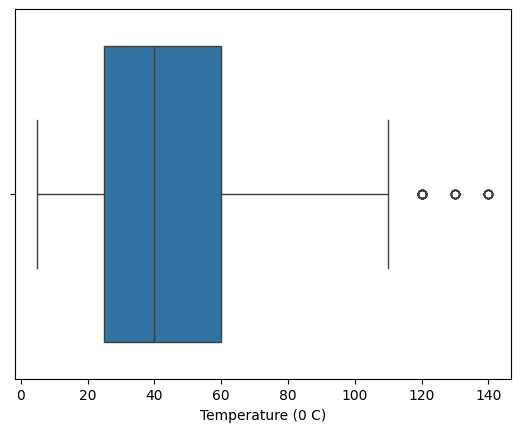

In [ ]:
sns.boxplot(x=df["Temperature (0 C)"])
#box-plot is used to see the statistical distribution of the data.
#the left most line represents min value in the column
#the subsequent 3 lines of blue box represent 25 percentile 50 percentile and 75 percentile values
# the last line represnt the max value to be not called an outlier
# the min and max are calculated using inter quartile range

<Axes: xlabel='Pressure (bar)'>

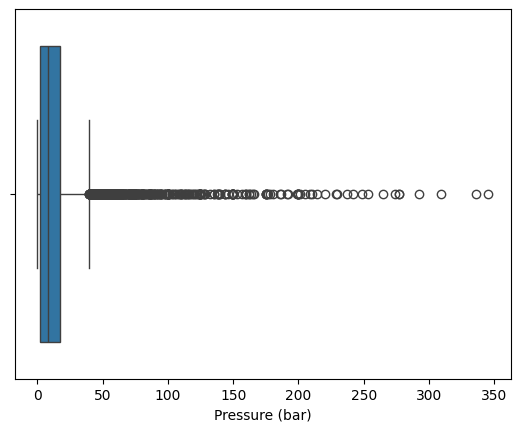

In [167]:
sns.boxplot(x=df1["Pressure (bar)"])

<Axes: xlabel='Pressure (bar)', ylabel='Count'>

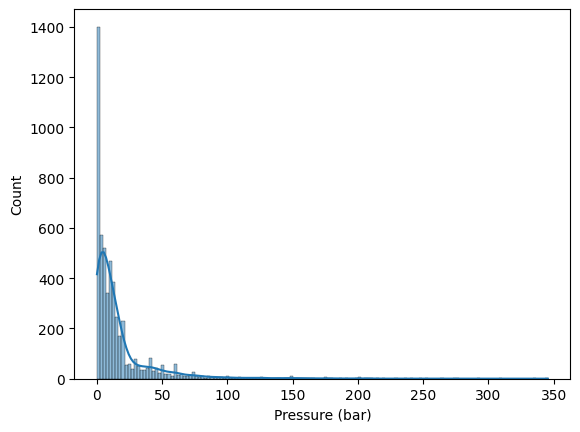

In [ ]:
sns.histplot(data=df1["Pressure (bar)"],kde=True)
#this is a distribution plot showing that the data is right skewed

In [169]:
df.columns

Index(['IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES', 'Anion_SMILES',
       'Temperature (0 C)', 'Pressure (bar)', 'CO2 capacity (mol CO2/mol IL)'],
      dtype='str')

In [ ]:
corr=df1[["Temperature (0 C)","Pressure (bar)","CO2 capacity (mol CO2/mol IL)"]].corr()
corr
# this is to check correlation between the colums
# this shows that presure is positively correlated with co2 solubility
# this also shows that temperature is negatively corellated with co2 solubility

,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
Temperature (0 C),1.000000,0.361796,-0.032505
Pressure (bar),0.361796,1.000000,0.495167
CO2 capacity (mol CO2/mol IL),-0.032505,0.495167,1.000000


<Axes: >

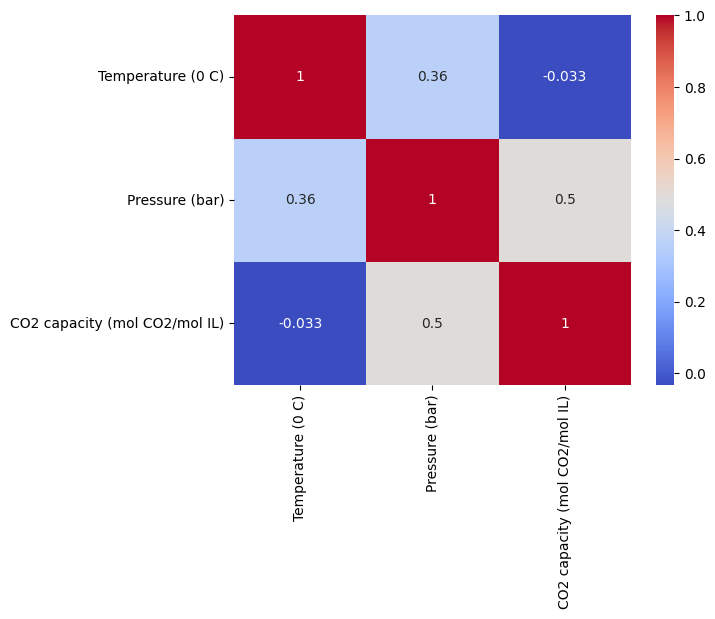

In [ ]:
sns.heatmap(corr,annot=True,cmap='coolwarm')
#this plot is just representation of the correlation data

<Axes: xlabel='CO2 capacity (mol CO2/mol IL)'>

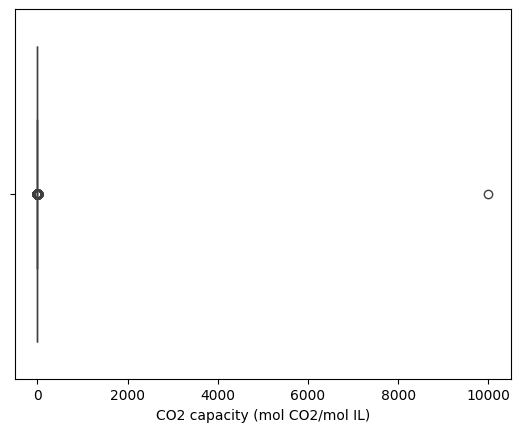

In [ ]:
sns.boxplot(x=df1["CO2 capacity (mol CO2/mol IL)"])
#one odd outlier data is present which is almost equal to 10000 where most values are around 0 to 10 range which is strange

In [ ]:
df1[df1["CO2 capacity (mol CO2/mol IL)"]>100]
#checking which column is the one having that outlier

,IL NAME,CATION NAME,ANION NAME,Cation_SMILES,Anion_SMILES,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
4720,[HMIM][NTf₂],1-hexyl-3-methylimidazolium,bis[(trifluoromethyl)sulfonyl]imide,CCCCCC[n+]1ccn(C)c1,FC(F)(F)S(=O)(=O)[N-]S(=O)(=O)C(F)(F)F,24.96,64.2,9999.0


In [174]:
df1["CO2 capacity (mol CO2/mol IL)"].sort_values().tail()

1561       6.692308
5130       7.032129
5122       7.431703
5123       8.293680
4720    9999.000000
Name: CO2 capacity (mol CO2/mol IL), dtype: float64

In [ ]:
df1=df1[df1["CO2 capacity (mol CO2/mol IL)"]<100]
#removing the row that contains the outlier

<Axes: xlabel='CO2 capacity (mol CO2/mol IL)'>

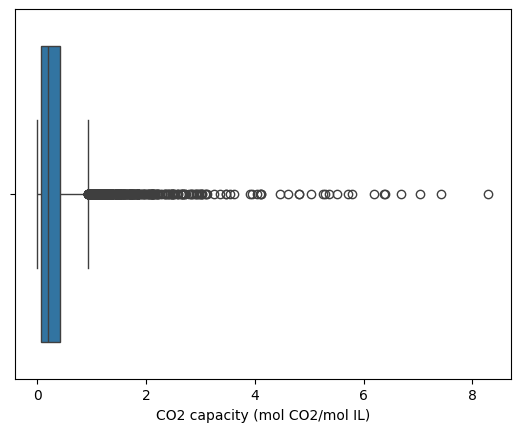

In [ ]:
sns.boxplot(x=df1["CO2 capacity (mol CO2/mol IL)"])
#now the distribution looks uniform

In [177]:
df1.columns

Index(['IL NAME', 'CATION NAME', 'ANION NAME', 'Cation_SMILES', 'Anion_SMILES',
       'Temperature (0 C)', 'Pressure (bar)', 'CO2 capacity (mol CO2/mol IL)'],
      dtype='str')

Text(0, 0.5, 'CO2 capacity (mol CO2/mol IL)')

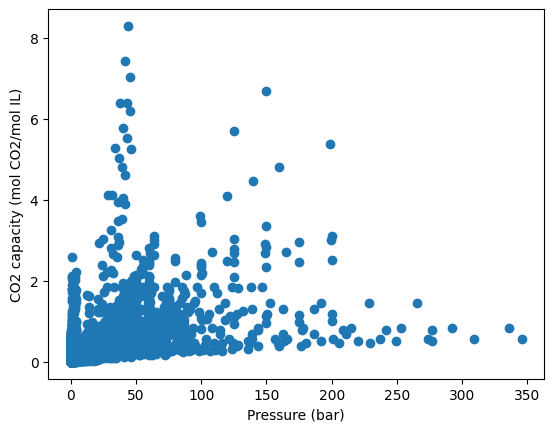

In [ ]:
plt.Figure(figsize=(20,20))
plt.scatter(x=df1["Pressure (bar)"],y=df1["CO2 capacity (mol CO2/mol IL)"])
plt.xlabel("Pressure (bar)")
plt.ylabel("CO2 capacity (mol CO2/mol IL)")
# this scatter plot shows that the distribution of pressure and co2 solubility is not linear at all

<Axes: xlabel='Pressure (bar)', ylabel='CO2 capacity (mol CO2/mol IL)'>

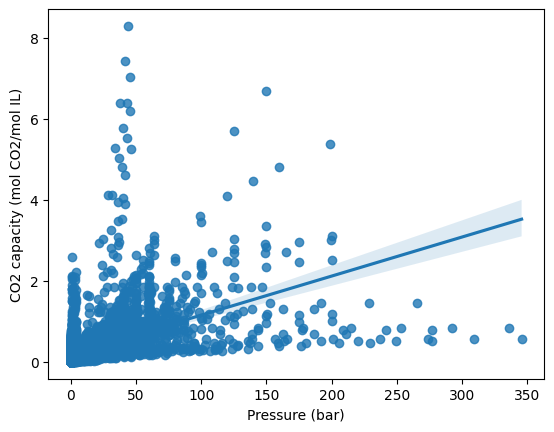

In [ ]:
sns.regplot(x=df1["Pressure (bar)"],y=df1["CO2 capacity (mol CO2/mol IL)"])
#this plot shows that the best fit line is unable to capture the relationship 

Text(0, 0.5, 'CO2 capacity (mol CO2/mol IL)')

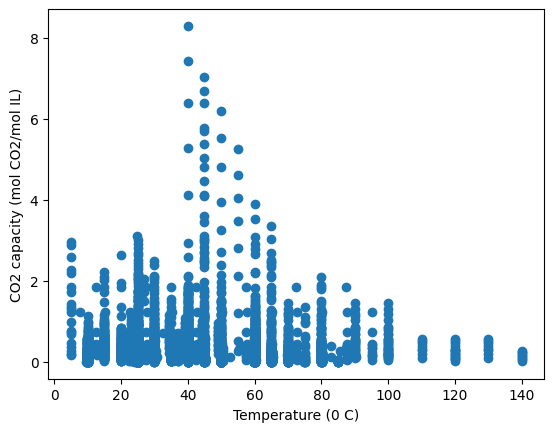

In [180]:
plt.scatter(x=df1["Temperature (0 C)"],y=df1["CO2 capacity (mol CO2/mol IL)"])
plt.xlabel("Temperature (0 C)")
plt.ylabel("CO2 capacity (mol CO2/mol IL)")

In [181]:
df1.describe()

,Temperature (0 C),Pressure (bar),CO2 capacity (mol CO2/mol IL)
count,5349.000000,5349.000000,5349.000000
mean,43.361554,16.809779,0.351997
std,21.041986,28.551239,0.556316
min,4.970000,0.000013,0.000000
25%,25.000000,2.000000,0.070664
50%,40.000000,8.442000,0.186000
75%,59.980000,17.100000,0.412429
max,139.950000,345.500000,8.293680


In [182]:
df1.to_csv( "../data/co2_solubility_cleaned.csv",index=False)